# Notebook 4

This is a notebook to test ABP and ABF on a simple one dimensional case with potential $V(x) = (1 - x^2)^2$

## Section 1

Calculate transition times simulating the whole process, also histograms

Transition detected at index: 122, time: 1.22


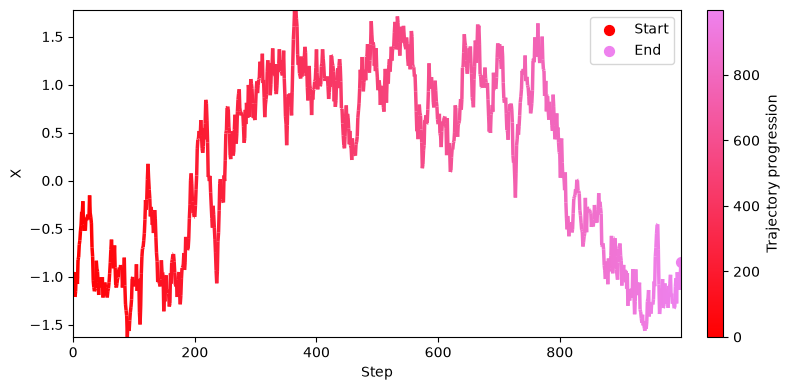

In [1]:
import numpy as np
from src.abp_abf.potential import Potential
from src.abp_abf.transition_detector import TransitionDetector
from src.brownian import BrownianMotion


dt = 0.01
potential = Potential(1, lambda x: (1 - x[0] ** 2) ** 2, lambda x: -4 * x[0] * (1 - x[0] ** 2))
bm = BrownianMotion(num_steps=1000, delta_t=dt, dimension=1, D=1, initial_position=np.array([-1.0]), b=lambda x: -potential.potential_prime_at(x))
bm.simulate()

td = TransitionDetector(bm.positions, lambda x: x[0], 0.0)
transition_index = td.detect_transition()
transition_time = transition_index * dt if transition_index is not None else None

print(f"Transition detected at index: {transition_index}, time: {transition_time}")
bm.plot_brownian_path(bm.positions, mode_1d="time_series", point_stride=10000)

In [2]:
import numpy as np
from src.abp_abf.potential import Potential
from src.abp_abf.transition_detector import TransitionDetector
from src.brownian import BrownianMotion
from src.statistics import Statistics
from joblib import Parallel, delayed


def run_one_simulation():
    dt = 0.001
    potential = Potential(1, lambda x: (1 - x[0] ** 2) ** 2, lambda x: -4 * x[0] * (1 - x[0] ** 2))


    bm = BrownianMotion(num_steps=10000, delta_t=dt, dimension=1, D=1, initial_position=np.array([-1.0]), b=lambda x: -potential.potential_prime_at(x))
    bm.simulate()

    td = TransitionDetector(bm.positions, lambda x: x[0], 0.0)
    transition_index = td.detect_transition()
    transition_time = transition_index * dt if transition_index is not None else None
    return transition_time

Mean transition time: 1.4723422106527835
Standard deviation of transition times: 1.3474240764520136


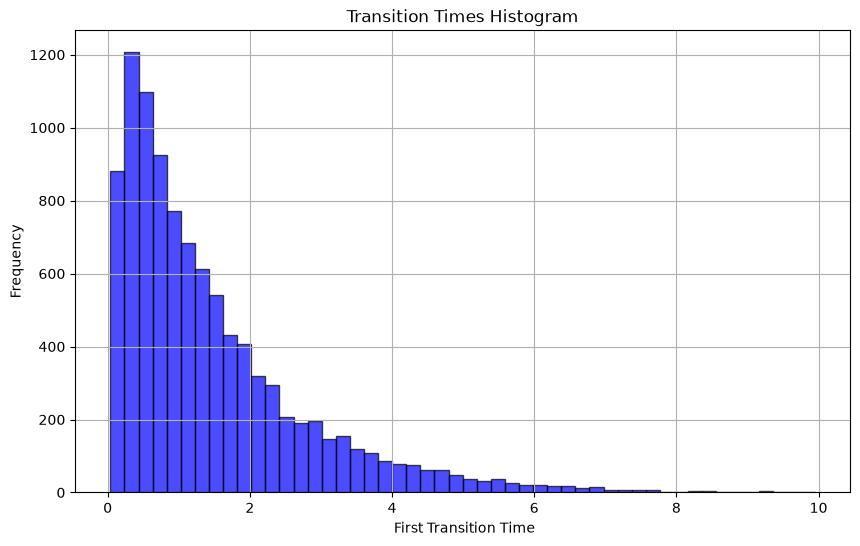

In [3]:
transition_times = []
exit_points = []

results = Parallel(n_jobs=-1)(
    delayed(run_one_simulation)()
    for _ in range(10000)
)

for transition_time in results:
    if transition_time is not None:
        transition_times.append(transition_time)

transition_times = np.array(transition_times)

mean_transition_time = np.mean(transition_times)

dev_transition_time = np.std(transition_times)

print(f"Mean transition time: {mean_transition_time}")
print(f"Standard deviation of transition times: {dev_transition_time}")
Statistics.plot_histogram(transition_times, bins=50, title="Transition Times Histogram", xlabel=" First Transition Time", ylabel="Frequency")

## Section 2

Implementing the ABP algorithm to find transition times

In [6]:
import numpy as np
from src.abp_abf.potential import Potential
from src.abp_abf.transition_detector import TransitionDetector
from src.abp_abf.abp_metadynamics import ABPMetaDynamics
from src.statistics import Statistics
from joblib import Parallel, delayed


def run_one_simulation():
    dt = 0.001
    potential = Potential(1, lambda x: (1 - x[0] ** 2) ** 2, lambda x: -4 * x[0] * (1 - x[0] ** 2))


    abp = ABPMetaDynamics(num_steps=50, td=TransitionDetector(np.array([]), lambda x: x[0], 0.0), delta_t=dt, dimension=1, D=1, initial_position=np.array([-1.0]), b=potential)
    transition_time, simulation_time = abp.simulate()

    return transition_time, transition_time /simulation_time

Mean transition time: 1.3773691454644064
Standard deviation of transition times: 1.1477926936500602
Mean acceleration factor: 124.93260255363768
Standard deviation of acceleration factors: 276.2058855213316


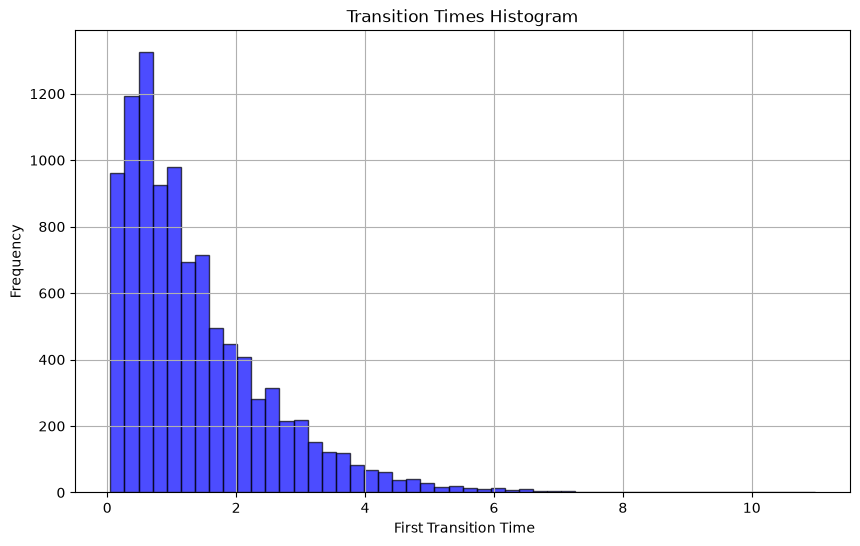

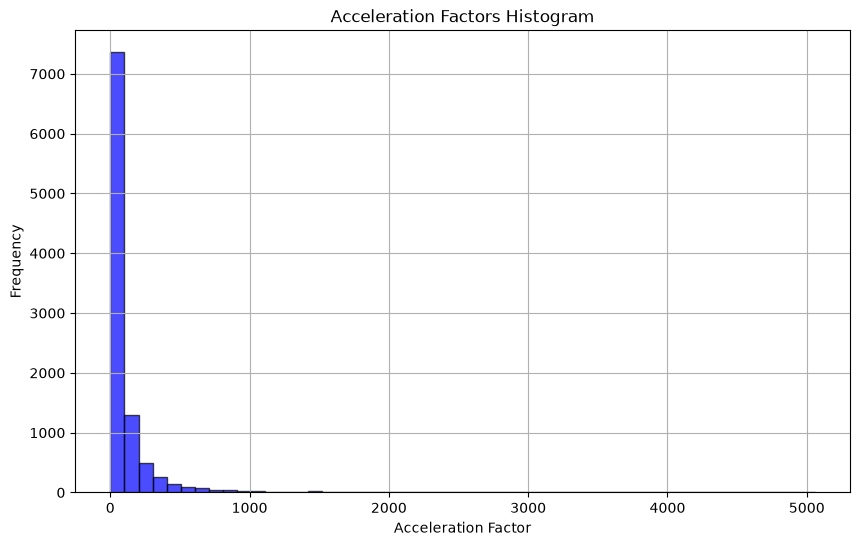

In [9]:
transition_times = []
acceleration_factors = []
exit_points = []

results = Parallel(n_jobs=-1)(
    delayed(run_one_simulation)()
    for _ in range(10000)
)

for transition_time, acc_factor in results:
    if transition_time is not None:
        transition_times.append(transition_time)
        acceleration_factors.append(acc_factor)

transition_times = np.array(transition_times)
acceleration_factors = np.array(acceleration_factors)

mean_transition_time = np.mean(transition_times)
mean_acceleration_factor = np.mean(acceleration_factors)

dev_transition_time = np.std(transition_times)
dev_acceleration_factor = np.std(acceleration_factors)

print(f"Mean transition time: {mean_transition_time}")
print(f"Standard deviation of transition times: {dev_transition_time}")

print(f"Mean acceleration factor: {mean_acceleration_factor}")
print(f"Standard deviation of acceleration factors: {dev_acceleration_factor}")

Statistics.plot_histogram(transition_times, bins=50, title="Transition Times Histogram", xlabel=" First Transition Time", ylabel="Frequency")
Statistics.plot_histogram(acceleration_factors, bins=50, title="Acceleration Factors Histogram", xlabel="Acceleration Factor", ylabel="Frequency")

Showing how the potential evolves for a specific case

Transition time: 0.339092260064181, Simulation time: 0.004, Acceleration factor: 84.77306501604524


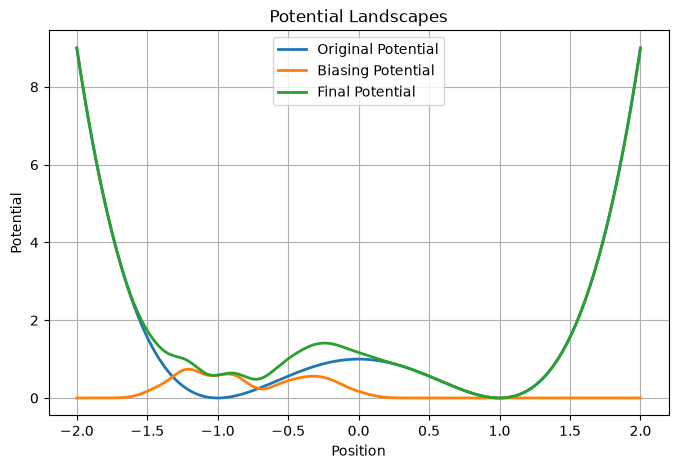

In [2]:
import numpy as np
from src.abp_abf.potential import Potential
from src.abp_abf.transition_detector import TransitionDetector
from src.abp_abf.abp_metadynamics import ABPMetaDynamics

dt = 0.001
potential = Potential(1, lambda x: (1 - x[0] ** 2) ** 2, lambda x: -4 * x[0] * (1 - x[0] ** 2))


abp = ABPMetaDynamics(num_steps=10, td=TransitionDetector(np.array([]), lambda x: x[0], 0.0), delta_t=dt, dimension=1, D=1, initial_position=np.array([-1.0]), b=potential, sigma=0.1)
transition_time, simulation_time = abp.simulate()

print(f"Transition time: {transition_time}, Simulation time: {simulation_time}, Acceleration factor: {transition_time / simulation_time}")
abp.plot_all_potentials()

## Section 3

This section will implement ABF to calculate free energy for the same potential as before

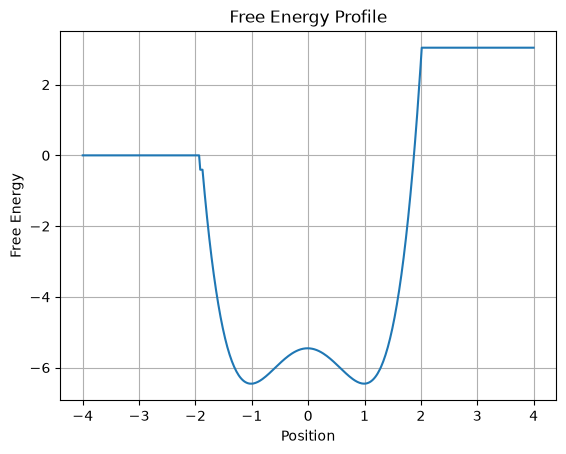

In [3]:
import numpy as np
from src.abp_abf.potential import Potential
from src.abp_abf.abf_simple import ABF

dt = 0.001
potential = Potential(1, lambda x: (1 - x[0] ** 2) ** 2, lambda x: -4 * x[0] * (1 - x[0] ** 2))


abf = ABF(num_steps=10000, delta_t=dt, D=1, initial_position=np.array([-1.0]), b=potential, bins=400, range=(-4, 4))
abf.simulate()
abf.free_energy()
abf.plot_free_energy()